# Model

## Enviroment setup

In [1]:
!pip install -q "transformers<5.0.0" tensorflow datasets tf_keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.6 MB/s eta 0:00:00


In [2]:
# Connect with Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Paths

BASE_PATH = "/content/drive/MyDrive/TEC/8vo IA/Proyecto IA"

PATHS = {
  "CLEAN_DATA_PATH": f"{BASE_PATH}/data/clean",
  "MODELS_PATH": f"{BASE_PATH}/models"
}

In [4]:
# Data manipulation
import pandas as pd
import numpy as np

# SciKit Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

# TensorFlow
import tensorflow as tf
import tf_keras as keras
from tf_keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tf_keras.layers import Bidirectional, LSTM, Dense, Reshape
from tf_keras.optimizers import Adam

# HuggingFace
from transformers import BertTokenizerFast, TFBertModel
from datasets import Dataset

# Plots
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from collections import Counter
from google.colab import userdata
import pickle
import warnings
import os

warnings.filterwarnings('ignore')

In [5]:
import platform
import tensorflow as tf

# Detect Apple Silicon
IS_APPLE_SILICON = (
    platform.system() == "Darwin" and
    platform.machine() == "arm64"
)

def _enable_metal_memory_growth(gpus: list) -> None:
    """Allow Metal to allocate GPU memory incrementally (avoids OOM errors)."""
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        # Must be set before GPUs are initialized
        print(f"[Warning] Memory growth must be set before GPU init: {e}")

# Device detection & configuration
gpus = tf.config.list_physical_devices("GPU")
tpus = tf.config.list_physical_devices("TPU")

if IS_APPLE_SILICON:
    chip = platform.processor() or "Apple Silicon"
    print(f"Apple Silicon detected: {chip}")

    if gpus:
        _enable_metal_memory_growth(gpus)
        print(f"\nMetal GPU available: {len(gpus)} device(s)")
        for gpu in gpus:
            print(f"  - {gpu.name}")
        print("TensorFlow-Metal is active — unified memory GPU acceleration enabled.")
    else:
        print(
            "\nNo Metal GPU found. Verify your install:\n"
            "  pip install tensorflow-macos tensorflow-metal\n"
            "Falling back to CPU."
        )

elif gpus:
    print(f"GPU detected: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"  - {gpu.name} ({gpu.device_type})")
    print("\nTensorFlow is configured to use the GPU.")

elif tpus:
    print(f"TPU detected: {len(tpus)} device(s)")
    for tpu in tpus:
        print(f"  - {tpu.name} ({tpu.device_type})")
    print("\nTensorFlow is configured to use the TPU.")

else:
    print(
        "No GPU or TPU detected.\n"
        "  • Google Colab: Runtime > Change runtime type > Hardware accelerator\n"
        "  • Apple Silicon: pip install tensorflow-macos tensorflow-metal"
    )

GPU detected: 1 device(s)
  - /physical_device:GPU:0 (GPU)

TensorFlow is configured to use the GPU.


## Data collection

In [6]:
# Parquet path

train_path = f"{PATHS['CLEAN_DATA_PATH']}/yelp_train.parquet"
val_path = f"{PATHS['CLEAN_DATA_PATH']}/yelp_val.parquet"
test_path = f"{PATHS['CLEAN_DATA_PATH']}/yelp_test.parquet"

df_train = pd.read_parquet(train_path)
df_val = pd.read_parquet(val_path)
df_test = pd.read_parquet(test_path)

# Show info to understand structure
print("\nInfo of Yelp Reviews:")
df_train.info()

print("\nSample:")
print(df_train.head().to_markdown(index=False))


Info of Yelp Reviews:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290514 entries, 0 to 290513
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   text       290514 non-null  object
 1   sentiment  290514 non-null  object
dtypes: object(2)
memory usage: 4.4+ MB

Sample:
| text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

## Data preparation



I'll separate the raw data into features and targets:
* Features (X): The 'text' column (raw text).
* Labels (y): The 'sentiment' column (class labels).

In [7]:
# Extract text and labels

print("\nExtracting text and labels...")

train_texts = df_train['text'].fillna('').astype(str).tolist()
val_texts = df_val['text'].fillna('').astype(str).tolist()
test_texts = df_test['text'].fillna('').astype(str).tolist()

train_labels = df_train['sentiment'].astype(str).tolist()
val_labels = df_val['sentiment'].astype(str).tolist()
test_labels = df_test['sentiment'].astype(str).tolist()

print(f"\nExample: {train_texts[0]}")


Extracting text and labels...

Example: I turned my 12-year old car over to them for a brake job; was informed I had a bigger problem.  Never asked the price because it didn't matter -- the car needed to be fixed and at that point I wasn't going to shop around for a better estimate.  Pleasantly surprised by the bill and the fact that I paid over the phone and they took my word for it that i had a $10 off coupon in my hand.  My ONLY complaint (because my old dealership used to do this) was when I picked it up almost $500 later, I was kind of hoping for an interior vacuum (which the car sorely needed.) Yes, I realize not everyone does this, but some do and that would have been a 5-star review.  But I do appreciate the great service and reasonable price.


Machine learning models require numerical input. I'll use LabelEncoder to convert the string sentiment labels into integers:
* negative -> 0
* neutral  -> 1
* positive -> 2

In [8]:
# Encode labels

print("\nEncoding labels...")

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_labels)
y_val = label_encoder.transform(val_labels)
y_test = label_encoder.transform(test_labels)

print(f"Classes: {label_encoder.classes_}")
print(f"Label distribution (train): {np.bincount(y_train)}")


Encoding labels...
Classes: ['negative' 'neutral' 'positive']
Label distribution (train): [96931 96645 96938]


### BERT tokenization

Converts raw text into `input_ids` and `attention_mask` using BERT's own WordPiece tokenizer — replacing the custom vocabulary pipeline.

- **`input_ids`:** Every token is mapped to its integer index in BERT's 30,000-word vocabulary.
- **`attention_mask`:** This is a binary array the same shape as `input_ids` and contains only ones and zeros:

  1. "this is a real token, pay attention to it"

  0. "this is padding, ignore it"

Also, I'm using a maximum sequence length of 256, according to Nkhata et al. (2025) for fine-grainned classification.

In [10]:
MODEL_NAME = "bert-base-uncased"
MAX_SEQUENCE_LENGTH = 256  # paper: 256 for fine-grained classification

tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME, token=userdata.get('hugging_face'))

def encode_texts(texts, tokenizer, max_len):
  ds = Dataset.from_dict({"text": texts})

  def tokenize_fn(batch):
    return tokenizer(
      batch["text"],
      max_length=max_len,
      padding="max_length",
      truncation=True,
    )

  encoded = ds.map(
    tokenize_fn,
    batched=True,
    batch_size=2000,
    num_proc=os.cpu_count(),
    desc="Tokenizing",
  )
  encoded.set_format(type="numpy", columns=["input_ids", "attention_mask"])

  return (
    np.array(encoded["input_ids"]).astype(np.int32),
    np.array(encoded["attention_mask"]).astype(np.int32),
  )

print("\nTokenizing with BERT WordPiece tokenizer...")
train_ids, train_mask = encode_texts(train_texts, tokenizer, MAX_SEQUENCE_LENGTH)
val_ids, val_mask = encode_texts(val_texts, tokenizer, MAX_SEQUENCE_LENGTH)
test_ids, test_mask = encode_texts(test_texts, tokenizer, MAX_SEQUENCE_LENGTH)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]


Tokenizing with BERT WordPiece tokenizer...


Tokenizing (num_proc=12):   0%|          | 0/290514 [00:00<?, ? examples/s]

Tokenizing (num_proc=12):   0%|          | 0/62253 [00:00<?, ? examples/s]

Tokenizing (num_proc=12):   0%|          | 0/62253 [00:00<?, ? examples/s]

In [11]:
BATCH_SIZE = 64 # (Nkhata et al. 2025)
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(ids, mask, labels, batch_size, shuffle=False):
  ds = tf.data.Dataset.from_tensor_slices(
    ({"input_ids": ids, "attention_mask": mask}, tf.one_hot(labels, depth=3))
  )
  if shuffle:
    ds = ds.shuffle(buffer_size=len(labels), seed=42)
  return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds = make_dataset(train_ids, train_mask, y_train, BATCH_SIZE, shuffle=True)
val_ds = make_dataset(val_ids, val_mask, y_val, BATCH_SIZE)
test_ds = make_dataset(test_ids, test_mask, y_test, BATCH_SIZE)


## Improved Model (Nkhata et al. 2025)

**BERT + BiLSTM + Attention**

The base model passed only the `[CLS]` token to BiLSTM, discarding all token-level context. Since sentiment depends on specific words — negations, intensifiers, contrasts — this model instead feeds the full `last_hidden_state` (all 256 token vectors) into the BiLSTM.

A Bahdanau additive attention layer (Bahdanau et al., 2015; Yang et al., 2016) then computes a weighted sum over the BiLSTM outputs, focusing on the most sentiment-relevant tokens.

### Model architecture

1. **`BERT`** (bert-base-uncased): produces a 768-dim contextual vector for every input token. Early layers frozen; fine-tuning focuses on the upper layers.

2. **`last_hidden_state`** (all 256 token vectors): unlike the base model, the full token sequence is passed to BiLSTM — not just the [CLS] aggregate.

3. **`BiLSTM`** (return_sequences=True): processes all 256 steps bidirectionally, producing a 128-dim hidden state at each position.

4. **`BahdanauAttention`**: scores each of the 256 hidden states, normalizes with softmax, and returns a single context vector weighted toward the most sentiment-relevant tokens.

5. **`Dense`** (3 units, softmax): neg / neutral / pos.

In [12]:
class BahdanauAttention(keras.layers.Layer):
  def __init__(self, units, **kwargs):
    super().__init__(**kwargs)
    self.units = units

    # Step 1: project each hidden state to a score
    # tanh keeps values in [-1, 1], which stabilizes training
    self.W = keras.layers.Dense(units, activation='tanh', name='attn_W')

    # Step 2: collapse to a single scalar score per timestep
    # No bias here — the bias in W already handles the offset
    self.V = keras.layers.Dense(1, use_bias=False, name='attn_V')

  def call(self, hidden_states):
    # hidden_states: (batch, seq_len, 2*lstm_units) = (batch, 256, 128)

    score = self.V(self.W(hidden_states))          # (batch, 256, 1)
    weights = tf.nn.softmax(score, axis=1)         # (batch, 256, 1)  — sums to 1 across positions
    context = tf.reduce_sum(weights * hidden_states, axis=1)  # (batch, 128)

    # Return both context vector (for classification) and
    # weights (for visualization — which tokens mattered most)
    return context, tf.squeeze(weights, axis=-1)   # (batch, 128), (batch, 256)

  def get_config(self):
    # Required so Keras can save/load this custom layer correctly
    config = super().get_config()
    config.update({"units": self.units})
    return config

In [14]:
# Model parameters
NUM_CLASSES=3
LSTM_UNITS = 64
ATTENTION_UNITS = 64
N_FROZEN_ENCODER_LAYERS = 6

# Load and freeze BERT

bert = TFBertModel.from_pretrained(MODEL_NAME, name="bert", use_safetensors=False)
bert.bert.embeddings.trainable = False
for i in range(N_FROZEN_ENCODER_LAYERS):
    bert.bert.encoder.layer[i].trainable = False
bert.bert.pooler.trainable = False

# Shared layer objects

bilstm_layer = keras.layers.Bidirectional(
    keras.layers.LSTM(LSTM_UNITS, return_sequences=True),
    name="bidirectional_lstm"
)
attention_layer = BahdanauAttention(units=ATTENTION_UNITS, name="attention")
output_layer    = keras.layers.Dense(NUM_CLASSES, activation="softmax", name="output")

# Define inputs

input_ids      = keras.Input(shape=(MAX_SEQUENCE_LENGTH,), dtype=tf.int32, name="input_ids")
attention_mask = keras.Input(shape=(MAX_SEQUENCE_LENGTH,), dtype=tf.int32, name="attention_mask")

# Forward pass

bert_out  = bert(input_ids=input_ids, attention_mask=attention_mask)
seq        = bert_out.last_hidden_state                # (batch, 256, 768) <- Difference
bilstm_out = bilstm_layer(seq)                         # (batch, 256, 128)
context, attn_weights = attention_layer(bilstm_out)    # (batch, 128), (batch, 256)
output    = output_layer(context)                      # (batch, 3)

# Bind inputs and outputs

model = keras.Model(
    inputs=[input_ids, attention_mask],
    outputs=output
    )

# Compile model

model.compile(
    optimizer=Adam(learning_rate=1e-4,   weight_decay=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

# Show architecture

print("\n Model Summary:")
model.summary()

tf_model.h5:   0%|          | 0.00/536M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at bert-base-uncased were not used when initializing TFBertModel: ['mlm___cls', 'nsp___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at bert-base-uncased.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training


 Model Summary:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 256)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 256)]                0         []                            
 )                                                                                                
                                                                                                  
 bert (TFBertModel)          TFBaseModelOutputWithPooli   1094822   ['input_ids[0][0]',           
                             ngAndCrossAttentions(last_   40         'attention_mask[0][0]']      
                             hidden_state=(None, 256, 7                      

In [15]:
# Training parameters
EPOCHS = 15  # paper: 15 for fine-grained classification

# mkdir
os.makedirs(PATHS["MODELS_PATH"], exist_ok=True)

# Callbacks
callbacks = [
    # Early stopping: stop if val_loss doesn't improve for 3 epochs
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    # Save best model
    ModelCheckpoint(
        f'{PATHS["MODELS_PATH"]}/improved_model_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    # Reduce learning rate if stuck
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1,
        min_lr=1e-6
    )
]

print(f"\n Training parameters:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Max epochs: {EPOCHS}")
print(f"   Callbacks: Early Stopping, Model Checkpoint, LR Reduction")


 Training parameters:
   Batch size: 64
   Max epochs: 15
   Callbacks: Early Stopping, Model Checkpoint, LR Reduction


### Training

In [16]:
# Train

improved_model_path = f'{PATHS["MODELS_PATH"]}/improved_model.keras'
improved_model_training_history_path = f'{PATHS["MODELS_PATH"]}/improved_model_training_history.pkl'

# Check if model exists to avoid retraining
if os.path.exists(improved_model_path) and os.path.exists(improved_model_training_history_path):
    print(f"\nModel found at {improved_model_path}. Loading...")
    model = keras.models.load_model(improved_model_path)
    print("Model loaded successfully. Skipping training.")
else:
    print("\nStarting training...\n")

    # Train model
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=val_ds,
        callbacks=callbacks,
        verbose=1
    )

    print("\nTraining complete!")

    # Save final model
    model.save(improved_model_path)
    print(f"Model saved to {improved_model_path}")

    # Save history
    with open(improved_model_training_history_path, 'wb') as f:
        pickle.dump(history.history, f)
    print(f"Training history saved to {improved_model_training_history_path}")


Starting training...

Epoch 1/15
4540/4540 [==============================] - ETA: 0s - loss: 0.4219 - accuracy: 0.8231 - precision: 0.8295 - recall: 0.8144
Epoch 1: val_accuracy improved from -inf to 0.83875, saving model to /content/drive/MyDrive/TEC/8vo IA/Proyecto IA/models/improved_model_best.keras
4540/4540 [==============================] - 1385s 298ms/step - loss: 0.4219 - accuracy: 0.8231 - precision: 0.8295 - recall: 0.8144 - val_loss: 0.3887 - val_accuracy: 0.8388 - val_precision: 0.8444 - val_recall: 0.8315 - lr: 1.0000e-04
Epoch 2/15
4540/4540 [==============================] - ETA: 0s - loss: 0.3619 - accuracy: 0.8494 - precision: 0.8530 - recall: 0.8450
Epoch 2: val_accuracy improved from 0.83875 to 0.84264, saving model to /content/drive/MyDrive/TEC/8vo IA/Proyecto IA/models/improved_model_best.keras
4540/4540 [==============================] - 1349s 297ms/step - loss: 0.3619 - accuracy: 0.8494 - precision: 0.8530 - recall: 0.8450 - val_loss: 0.3822 - val_accuracy: 0.8

### Results


Loading training history...
Training statistics:

Best epoch: 2/5
Best validation accuracy: 0.8426 (84.26%)
Best validation loss: 0.3822

Final epoch:
    Train accuracy: 0.9147 (91.47%)
    Val accuracy: 0.8394 (83.94%)

Slight overfitting (gap: 0.0752)

Generating Confusion Matrix on Test Set...
973/973 [==============================] - 127s 131ms/step


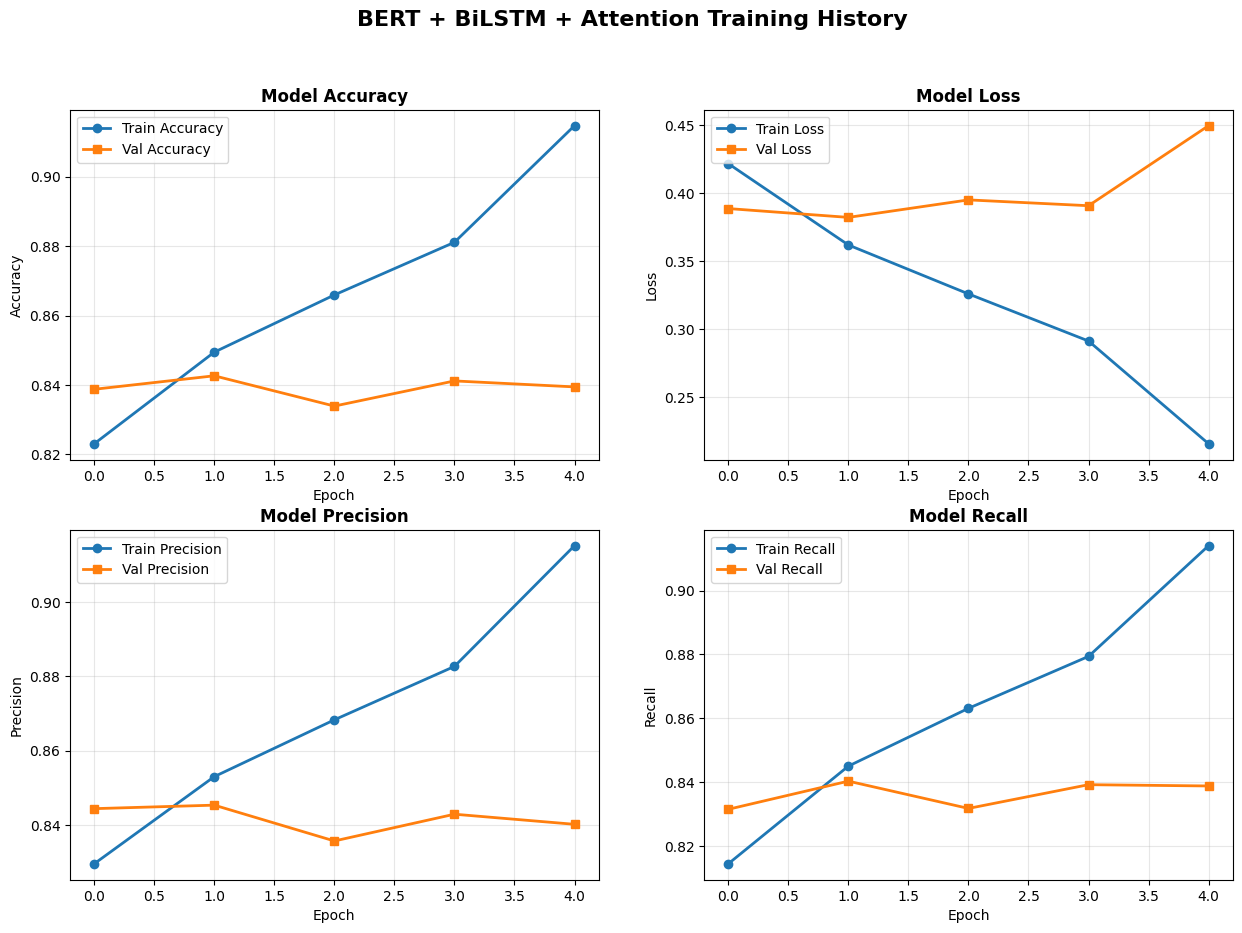

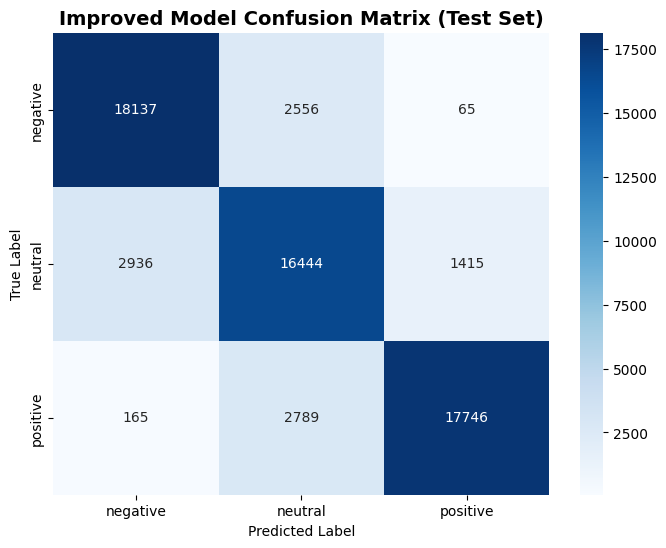

In [19]:
# Results

# Load training history
print("\nLoading training history...")

with open(improved_model_training_history_path, 'rb') as f:
    history_dict = pickle.load(f)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('BERT + BiLSTM + Attention Training History', fontsize=16, fontweight='bold')

# 1. Accuracy
axes[0, 0].plot(history_dict['accuracy'], label='Train Accuracy', linewidth=2, marker='o')
axes[0, 0].plot(history_dict['val_accuracy'], label='Val Accuracy', linewidth=2, marker='s')
axes[0, 0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Loss
axes[0, 1].plot(history_dict['loss'], label='Train Loss', linewidth=2, marker='o')
axes[0, 1].plot(history_dict['val_loss'], label='Val Loss', linewidth=2, marker='s')
axes[0, 1].set_title('Model Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Precision
axes[1, 0].plot(history_dict['precision'], label='Train Precision', linewidth=2, marker='o')
axes[1, 0].plot(history_dict['val_precision'], label='Val Precision', linewidth=2, marker='s')
axes[1, 0].set_title('Model Precision', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Recall
axes[1, 1].plot(history_dict['recall'], label='Train Recall', linewidth=2, marker='o')
axes[1, 1].plot(history_dict['val_recall'], label='Val Recall', linewidth=2, marker='s')
axes[1, 1].set_title('Model Recall', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Print statistics
print("Training statistics:")

best_epoch = np.argmax(history_dict['val_accuracy']) + 1
best_val_acc = np.max(history_dict['val_accuracy'])
best_val_loss = np.min(history_dict['val_loss'])
final_train_acc = history_dict['accuracy'][-1]
final_val_acc = history_dict['val_accuracy'][-1]

print(f"\nBest epoch: {best_epoch}/{len(history_dict['loss'])}")
print(f"Best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"\nFinal epoch:")
print(f"    Train accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"    Val accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")

# Check for overfitting
overfit_gap = final_train_acc - final_val_acc
if overfit_gap > 0.1:
    print(f"\nPotential overfitting detected (gap: {overfit_gap:.4f})")
elif overfit_gap > 0.05:
    print(f"\nSlight overfitting (gap: {overfit_gap:.4f})")
else:
    print(f"\nGood generalization (gap: {overfit_gap:.4f})")

# --- Confusion Matrix ---
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("\nGenerating Confusion Matrix on Test Set...")
y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Improved Model Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()